**Loading the Dataset**

In [9]:
#Import libraries
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import tensorflow_hub as hub
# Load the training data

#Replace the path above with the folder where YOUR file is saved
#Example: train_data = pd.read_csv("C:/Users/YourName/Documents/train.csv")
df = pd.read_csv("archive/spam.csv", encoding='latin-1')
df.head()


c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**Basic Data Cleaning (Preprocessing)**

In [10]:
# Drop columns
#cols_to_drop = ['education','relationship','education_num']
#X_train = X_train.drop(columns=cols_to_drop)
#X_test = X_test.drop(columns=cols_to_drop)
cols_to_drop=['Unnamed: 2','Unnamed: 3','Unnamed: 4']
df=df.drop(cols_to_drop,axis=1)
df.rename(columns={'v1':'classification','v2':'content'},inplace=True)
df['classification_enc'] = df['classification'].map({'ham': 0, 'spam': 1})
df.head()

,classification,content,classification_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


**Splitting the Data**

In [11]:
# Split: 80% for training, 20% for testing our accuracy
X_train, X_test, y_train, y_test = train_test_split(df['content'],df['classification_enc'], test_size=0.2, random_state=42)
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [12]:
avg_words_len = round(sum([len(i.split())
                      for i in df['content']]) / len(df['content']))
total_words_length = len(set(" ".join(df['content']).split()))

print(f"Data Loaded. Training samples: {len(X_train)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 15
Approximate vocabulary size: 15585


In [13]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

In [14]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

**Training a Basic Classification Model**

In [16]:

input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8659 - loss: 0.3837 - val_accuracy: 0.9650 - val_loss: 0.1565
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9780 - loss: 0.0903 - val_accuracy: 0.9758 - val_loss: 0.0873
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9910 - loss: 0.0330 - val_accuracy: 0.9767 - val_loss: 0.0824
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9960 - loss: 0.0160 - val_accuracy: 0.9794 - val_loss: 0.0900
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9985 - loss: 0.0065 - val_accuracy: 0.9758 - val_loss: 0.0854


In [17]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8941 - loss: 0.2925 - val_accuracy: 0.9776 - val_loss: 0.0840
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9913 - loss: 0.0318 - val_accuracy: 0.9812 - val_loss: 0.0988
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9987 - loss: 0.0065 - val_accuracy: 0.9839 - val_loss: 0.0985
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9999 - loss: 6.4732e-04 - val_accuracy: 0.9830 - val_loss: 0.1237
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9803 - val_loss: 0.1176


In [18]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5



140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8704 - loss: 0.4449 - val_accuracy: 0.9722 - val_loss: 0.1112
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9739 - loss: 0.0954 - val_accuracy: 0.9776 - val_loss: 0.0690
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9862 - loss: 0.0567 - val_accuracy: 0.9803 - val_loss: 0.0585
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9910 - loss: 0.0413 - val_accuracy: 0.9812 - val_loss: 0.0534
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9875 - loss: 0.0362 - val_accuracy: 0.9821 - val_loss: 0.0505


In [19]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.975785   0.936170  0.880000  0.907216
Bi-LSTM                  0.980269   0.950704  0.900000  0.924658
Transfer Learning (USE)  0.982063   0.951389  0.913333  0.931973


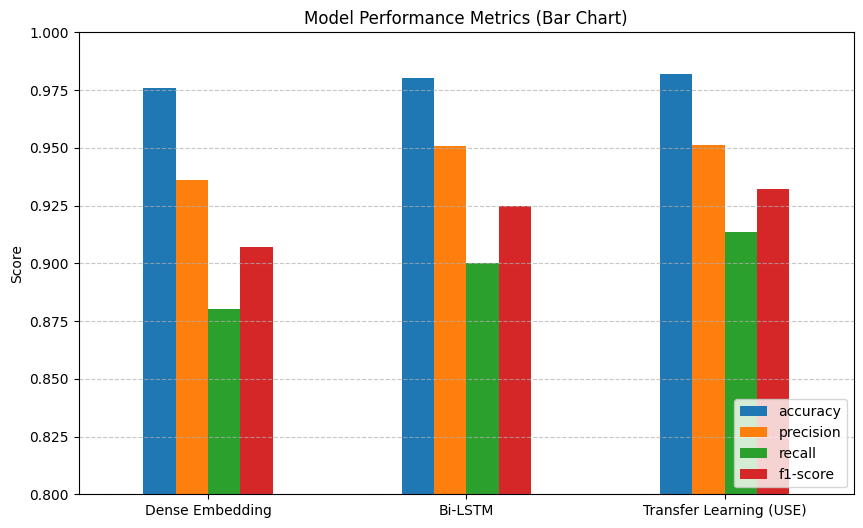

In [20]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

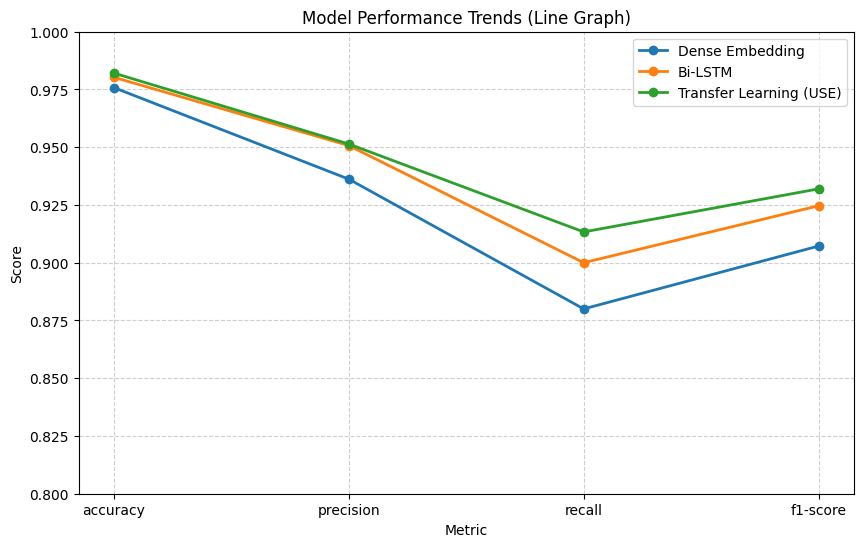

In [21]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()